# 03 · Vertical bridge to EVRS

`H_EVRS_EGG2015 = ht_water_surf − zeta_EGG2015`. `ht_ortho` (EGM2008) is kept only as an independent control: `egm2008_minus_evrs_m` must be small & smooth.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'src'))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from kakhovka_altimetry.config import load_config
from kakhovka_altimetry.io import read_parquet
cfg = load_config()


In [2]:
evrs = read_parquet(cfg.evrs_parquet)
evrs[['h_wgs84_m','H_egm2008_m','zeta_egg2015_m','H_evrs_egg2015_m','egm2008_minus_evrs_m']].describe()

,h_wgs84_m,H_egm2008_m,zeta_egg2015_m,H_evrs_egg2015_m,egm2008_minus_evrs_m
count,513873.000000,513873.000000,513873.000000,513873.000000,513873.000000
mean,36.038166,13.812019,22.080792,13.957373,-0.145354
std,4.121593,4.246707,0.563093,4.245767,0.027236
min,22.343172,-0.451750,21.058884,-0.340598,-0.200868
25%,36.505337,14.402596,21.512557,14.545918,-0.168983
50%,37.661045,15.736825,22.188035,15.877386,-0.139067
75%,38.373764,15.911472,22.600905,16.053872,-0.121602
max,94.000687,72.437347,23.040093,72.600524,-0.101877


In [3]:
d = evrs['egm2008_minus_evrs_m'].dropna()
print(f'egm2008_minus_evrs_m: mean {d.mean():.3f}  std {d.std():.3f}  [{d.min():.3f}, {d.max():.3f}] m')

egm2008_minus_evrs_m: mean -0.145  std 0.027  [-0.201, -0.102] m


### Spatial smoothness of the EGM2008 − EVRS diagnostic

Text(0, 0.5, 'lat')

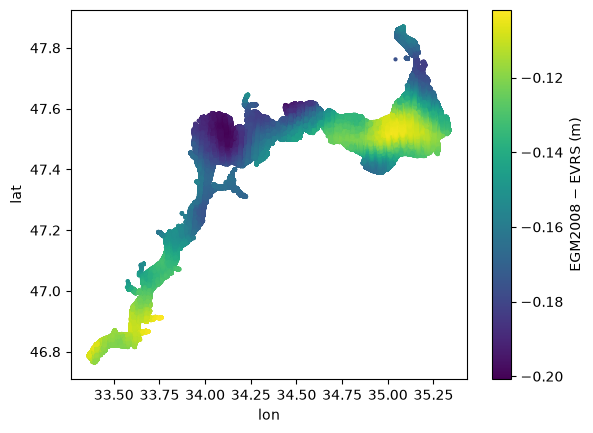

In [4]:
sc = plt.scatter(evrs['lon'], evrs['lat'], c=evrs['egm2008_minus_evrs_m'], s=4)
plt.colorbar(sc, label='EGM2008 − EVRS (m)'); plt.xlabel('lon'); plt.ylabel('lat')

### ellipsoidal vs EGM2008 vs EVRS for one pass

Text(0, 0.5, 'height (m)')

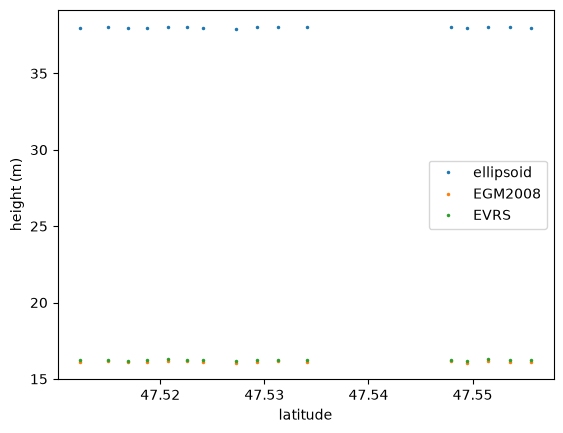

In [5]:
g = evrs.groupby([pd.to_datetime(evrs['time']).dt.date, 'rgt', evrs.get('beam')])
seg = g.get_group(list(g.groups)[len(g.groups)//2]).sort_values('lat')
for c,l in [('h_wgs84_m','ellipsoid'),('H_egm2008_m','EGM2008'),('H_evrs_egg2015_m','EVRS')]:
    plt.plot(seg['lat'], seg[c], '.', ms=3, label=l)
plt.legend(); plt.xlabel('latitude'); plt.ylabel('height (m)')